<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/Peta2_Indeks_Sampah_Kec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
# ==========================================================================
#    STRUKTUR PENGELOLAAN SAMPAH KECAMATAN DI KOTA DUMAI
# ==========================================================================

import pandas as pd
import matplotlib.pyplot as plt

In [66]:
# unduh dokumen dari google sheet
#CATATAN : 1) STATUS FILE : share everyone   2) Nama file yg dipakai ID nya (tengok di kolom link https nya)

url = "https://docs.google.com/spreadsheets/d/1DoMXP81Kt1yK2C1Y-c_jhPQlYghqfBKqD8o9ZYOErVA/export?format=csv"

df = pd.read_csv(url)

df

,No,nama_kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,%RT,RT,Terolah,Reduksi,Liar,Hidden,Leaked,%Leaked
0,1,Dumai Timur,67000,0.8,53600,25%,13400.0,100,0.01,536,636,500,1000,38064.0,39064.0,72.88
1,2,Dumai Barat,44200,0.7,30940,70%,21658.0,750,0.15,4641,5391,2000,1600,291.0,1891.0,6.11
2,3,Bukit Kapur,49000,0.7,34300,50%,17150.0,1000,0.25,8575,9575,4000,2500,1075.0,3575.0,10.42
3,4,Medang Kampai,14500,0.7,10150,25%,2537.5,1500,0.10,1015,2515,2000,3000,97.5,3097.5,30.52
4,5,Sungai Sembilan,38000,0.7,26600,0%,0.0,2000,0.20,5320,7320,1500,1500,16280.0,17780.0,66.84


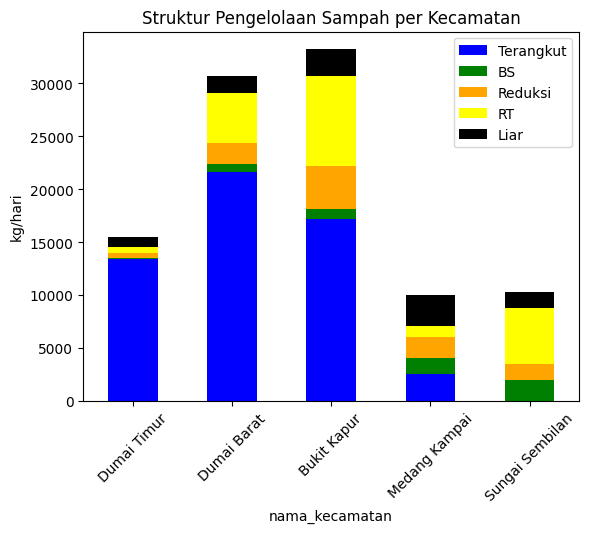

In [67]:
# pembuatan diagram batang struktur pengelolaan sampah per kecamatan
# ========================================================================

df_plot = df.set_index("nama_kecamatan")[["Terangkut","BS","Reduksi","RT","Liar"]]
#CATATAN :
#   Terangkut = pelayanan armada pemkot
#   BS = Bank Sampah, TPST, TPS3R
#   RT = pengurangan sampah di RT (asumsi)
#   Reduksi = Lapak, Kawasan dll
#   Liar = TPS Liar, sampah menumpuk tanpa izin (bisa difoto)
#   Hidden = neraca massa sampah BALANCE

df_plot.plot(kind="bar", stacked=True,
             color={"Terangkut":"blue",
             "BS":"green",
             "Reduksi":"orange",
             "RT":"yellow",
             "Liar":"black"})

plt.title("Struktur Pengelolaan Sampah per Kecamatan")

plt.ylabel("kg/hari")

plt.xticks(rotation=45)

plt.show()

# 📊 WLSRI (Waste Local Service Resilience Index)

## 1. Definisi

**WLSRI (Waste Local Service Resilience Index)** adalah indeks komposit yang digunakan untuk menilai tingkat **kemandirian dan ketahanan sistem pengelolaan sampah** di suatu wilayah (misalnya kecamatan).

Indeks ini menggambarkan kemampuan wilayah dalam:

* menangani sampah yang dihasilkan,
* mengurangi ketergantungan pada sistem eksternal,
* meminimalkan kebocoran sampah ke lingkungan.

---

## 2. Komponen Penyusun

WLSRI disusun dari 4 komponen utama:

### 1. SPI (Service Performance Index)

Menggambarkan tingkat pelayanan pengangkutan sampah.

[
SPI = {Terangkut} / {Timbulan}
]

---

### 2. Reduksi Ratio

Menggambarkan kemampuan pengurangan sampah dari sumber (misalnya bank sampah, komposting).

[
Reduksi Ratio = {Reduksi} / {Timbulan}
]

---

### 3. Terolah Ratio

Menggambarkan kemampuan pengolahan sampah di dalam sistem.

[
Terolah Ratio = {Terolah} / {Timbulan}
]

---

### 4. Leakage Index

Menggambarkan tingkat kebocoran sampah ke lingkungan.

[
Leakage Index = {un-Manage} / {Timbulan}
]

dimana:
[
un-Manage = Liar + Hidden
]

---

## 3. Rumus WLSRI

[
WLSRI = (0.4 * SPI) + (0.2 * Reduksi Ratio) + (0.2 * Terolah Ratio) - (0.2 * Leakage Index)
]

---

## 4. Interpretasi Nilai

| Nilai WLSRI | Interpretasi                       |
| ----------- | ---------------------------------- |
| > 0.70      | Sistem sangat mandiri dan efektif  |
| 0.50 – 0.70 | Sistem cukup baik                  |
| 0.30 – 0.50 | Sistem sedang, perlu intervensi    |
| < 0.30      | Sistem lemah, prioritas penanganan |

---

## 5. Makna Analitis

WLSRI memberikan gambaran keseimbangan antara:

✔ **Kinerja pelayanan (SPI)**
✔ **Upaya pengurangan (Reduksi)**
✔ **Kapasitas pengolahan (Terolah)**
❌ **Kebocoran sistem (Leakage)**

Sehingga indeks ini dapat digunakan untuk:

* menentukan prioritas intervensi kebijakan,
* membandingkan kinerja antar kecamatan,
* mengidentifikasi titik lemah sistem pengelolaan sampah.

---

## 6. Catatan Penting

* Bobot (0.4, 0.2, 0.2, 0.2) dapat disesuaikan dengan kebijakan daerah.
* WLSRI bersifat **komparatif**, sehingga lebih kuat digunakan untuk perbandingan antar wilayah.
* Akurasi indeks sangat bergantung pada kualitas data timbulan dan pengelolaan.

---


In [68]:
# Nilai WRSRI
# ====================================================================
# perhitungan nilai SPI, Reduksi Ratio, Terolah Ratio, Leakage Index => nilai WLSRI

df['SPI'] = df['Terangkut'] / df['Timbulan']
df['Reduksi_Ratio'] = df['Reduksi'] / df['Timbulan']
df['Terolah_Ratio'] = df['Terolah'] / df['Timbulan']

df['un-Manage'] = df['Timbulan'] - (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Leakage_Index'] = df['un-Manage'] / df['Timbulan']

df['WLSRI'] = (
    0.5 * df['SPI'] +
    0.15 * df['Reduksi_Ratio'] +
    0.25 * df['Terolah_Ratio'] -
    0.1 * df['Leakage_Index']
)

df = df.sort_values(by='WLSRI', ascending=False)

df

,No,nama_kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,%RT,RT,...,Liar,Hidden,Leaked,%Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,un-Manage,Leakage_Index,WLSRI
1,2,Dumai Barat,44200,0.7,30940,70%,21658.0,750,0.15,4641,...,1600,291.0,1891.0,6.11,0.70,0.064641,0.174240,1891.0,0.061118,0.397144
2,3,Bukit Kapur,49000,0.7,34300,50%,17150.0,1000,0.25,8575,...,2500,1075.0,3575.0,10.42,0.50,0.116618,0.279155,3575.0,0.104227,0.326859
3,4,Medang Kampai,14500,0.7,10150,25%,2537.5,1500,0.10,1015,...,3000,97.5,3097.5,30.52,0.25,0.197044,0.247783,3097.5,0.305172,0.185985
0,1,Dumai Timur,67000,0.8,53600,25%,13400.0,100,0.01,536,...,1000,38064.0,39064.0,72.88,0.25,0.009328,0.011866,39064.0,0.728806,0.056485
4,5,Sungai Sembilan,38000,0.7,26600,0%,0.0,2000,0.20,5320,...,1500,16280.0,17780.0,66.84,0.00,0.056391,0.275188,17780.0,0.668421,0.010414


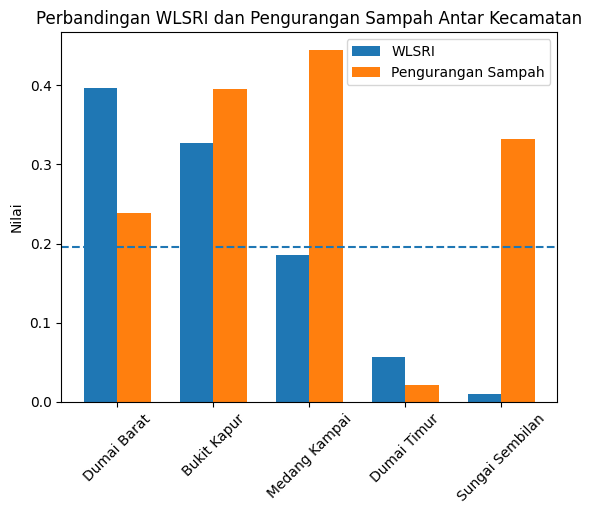

In [69]:
# Diagram Batang Perbandingan WLSRI dan Index_Pengurangan

import numpy as np

# pastikan sudah ada kolom ini
df['Indek_Pengurangan'] = (df['Reduksi'] + df['Terolah']) / df['Timbulan']

# urutkan
df = df.sort_values(by='WLSRI', ascending=False)

x = np.arange(len(df))
width = 0.35

plt.figure()

plt.bar(x - width/2, df['WLSRI'], width, label='WLSRI')
plt.bar(x + width/2, df['Indek_Pengurangan'], width, label='Pengurangan Sampah')

plt.xticks(x, df['nama_kecamatan'], rotation=45)
plt.ylabel("Nilai")
plt.title("Perbandingan WLSRI dan Pengurangan Sampah Antar Kecamatan")

plt.axhline(df['WLSRI'].mean(), linestyle='--')

plt.legend()
plt.show()

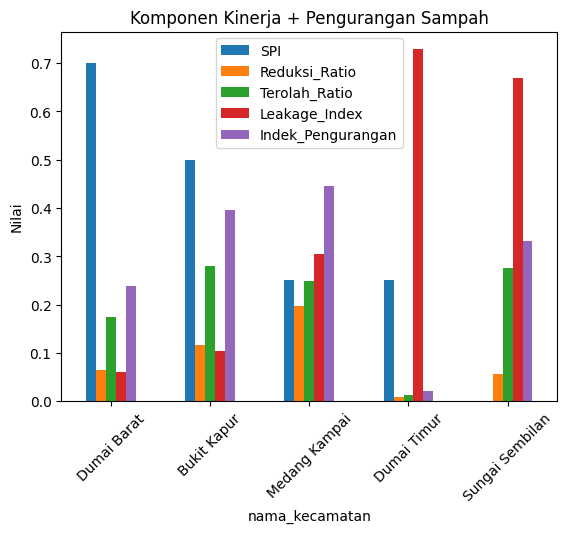

In [70]:
# Diagram Batang Struktur Pengelolaan Sampah

df_plot = df.set_index('nama_kecamatan')[[
    'SPI', 'Reduksi_Ratio', 'Terolah_Ratio',
    'Leakage_Index', 'Indek_Pengurangan'
]]

df_plot.plot(kind='bar')
plt.title("Komponen Kinerja + Pengurangan Sampah")
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.show()

In [71]:
# ANALISIS
# ===========================================================================

# Validasi dasar
df['Total_Terkelola'] = (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Tidak_Terkelola'] = df['Timbulan'] - df['Total_Terkelola']

def klasifikasi_kebocoran(row):

    if row['Timbulan'] == 0:
        return "DATA TIDAK VALID"

    rasio = row['Tidak_Terkelola'] / row['Timbulan']

    df['%Leakage'] = df['Tidak_Terkelola'] / df['Timbulan'] * 100

    if rasio > 0.7:
        return "KRISIS"
    elif rasio > 0.5:
        return "TINGGI"
    elif rasio > 0.3:
        return "SEDANG"
    else:
        return "RENDAH"

In [72]:
df['Kategori_Kebocoran'] = df.apply(klasifikasi_kebocoran, axis=1)

In [73]:
df[['nama_kecamatan','Tidak_Terkelola','Timbulan','%Leakage','Kategori_Kebocoran']]

,nama_kecamatan,Tidak_Terkelola,Timbulan,%Leakage,Kategori_Kebocoran
1,Dumai Barat,1891.0,30940,6.111829,RENDAH
2,Bukit Kapur,3575.0,34300,10.422741,RENDAH
3,Medang Kampai,3097.5,10150,30.517241,SEDANG
0,Dumai Timur,39064.0,53600,72.880597,KRISIS
4,Sungai Sembilan,17780.0,26600,66.842105,TINGGI


In [74]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1DoMXP81Kt1yK2C1Y-c_jhPQlYghqfBKqD8o9ZYOErVA/export?format=csv"
df = pd.read_csv(url)

df.head()

,No,nama_kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,%RT,RT,Terolah,Reduksi,Liar,Hidden,Leaked,%Leaked
0,1,Dumai Timur,67000,0.8,53600,25%,13400.0,100,0.01,536,636,500,1000,38064.0,39064.0,72.88
1,2,Dumai Barat,44200,0.7,30940,70%,21658.0,750,0.15,4641,5391,2000,1600,291.0,1891.0,6.11
2,3,Bukit Kapur,49000,0.7,34300,50%,17150.0,1000,0.25,8575,9575,4000,2500,1075.0,3575.0,10.42
3,4,Medang Kampai,14500,0.7,10150,25%,2537.5,1500,0.10,1015,2515,2000,3000,97.5,3097.5,30.52
4,5,Sungai Sembilan,38000,0.7,26600,0%,0.0,2000,0.20,5320,7320,1500,1500,16280.0,17780.0,66.84


In [75]:
df["persen_kebocoran"] = (df["Timbulan"] - (df["Terangkut"] + df["Terolah"] + df["Reduksi"])) / df["Timbulan"] * 100

In [76]:
# Cek penamaan di gdf dan df  =>  jika ada beda diset spt matching saat proses pemetaan
# Cek label yg ada di file peta

print(gdf.columns)
print(df.columns)

Index(['nama_kecamatan', 'geometry', 'No', 'Penduduk', 'Rasio', 'Timbulan',
       '% pelayanan', 'Terangkut', 'BS', '%RT', 'RT', 'Terolah', 'Reduksi',
       'Liar', 'Hidden', 'Leaked', '%Leaked', 'persen_kebocoran', 'kategori'],
      dtype='object')
Index(['No', 'nama_kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '% pelayanan',
       'Terangkut', 'BS', '%RT', 'RT', 'Terolah', 'Reduksi', 'Liar', 'Hidden',
       'Leaked', '%Leaked', 'persen_kebocoran'],
      dtype='object')


In [77]:
import geopandas as gpd
import requests
import zipfile

# UNDUH PETA : Download GADM Indonesia (level kecamatan) -  PENTING SAAT NEW NOTEBOOK
# download GADM
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IDN_shp.zip"
r = requests.get(url)

with open("gadm.zip", "wb") as f:
    f.write(r.content)

# extract
with zipfile.ZipFile("gadm.zip", 'r') as zip_ref:
    zip_ref.extractall("gadm")

# 1. BACA SHAPEFILE
# =============================================================================

# baca kecamatan se Indonesia
gdf = gpd.read_file("gadm/gadm41_IDN_3.shp")

# filter Dumai  (pilih di list NAME_2 yg Dumai)
gdf = gdf[gdf["NAME_2"] == "Dumai"]

# ambil kolom penting  (pilih kolom kecamatan yg poligon) dan kmdn ganti nama suai tabel
gdf = gdf[["NAME_3", "geometry"]]
gdf = gdf.rename(columns={"NAME_3": "nama_kecamatan"})

print(len(gdf))    # idealnya yg muncul 7 kecamatan, jika tertulis 5 berarti data peta blm update
gdf.head()

5


,nama_kecamatan,geometry
4769,Bukit Kapur,"POLYGON ((101.51488 1.48169, 101.5132 1.48171,..."
4770,Dumai Barat,"POLYGON ((101.37273 1.60609, 101.37228 1.60591..."
4771,Dumai Timur,"POLYGON ((101.41179 1.60181, 101.41528 1.6028,..."
4772,Medang Kampai,"POLYGON ((101.51763 1.48456, 101.51744 1.4844,..."
4773,Sungai Sembilan,"POLYGON ((101.3336 1.61594, 101.33317 1.61575,..."


In [78]:
# inti analisis

df["nama_kecamatan"] = df["nama_kecamatan"].str.lower()
gdf["nama_kecamatan"] = gdf["nama_kecamatan"].str.lower()

#  2. DATA +  MERGE
# =============================================================================

gdf = gdf.merge(df, on="nama_kecamatan")

In [79]:
# setelah merge

# 3. KATEGORI
# ============================================================================

def klasifikasi(x):
    if x > 70:
        return "KRISIS"
    elif x > 50:
        return "TINGGI"
    elif x > 30:
        return "SEDANG"
    else:
        return "RENDAH"

gdf["kategori"] = gdf["persen_kebocoran"].apply(klasifikasi)

In [80]:
print(gdf.columns)
print(df.columns)
print(gdf.head())
print(df.head())

Index(['nama_kecamatan', 'geometry', 'No', 'Penduduk', 'Rasio', 'Timbulan',
       '% pelayanan', 'Terangkut', 'BS', '%RT', 'RT', 'Terolah', 'Reduksi',
       'Liar', 'Hidden', 'Leaked', '%Leaked', 'persen_kebocoran', 'kategori'],
      dtype='object')
Index(['No', 'nama_kecamatan', 'Penduduk', 'Rasio', 'Timbulan', '% pelayanan',
       'Terangkut', 'BS', '%RT', 'RT', 'Terolah', 'Reduksi', 'Liar', 'Hidden',
       'Leaked', '%Leaked', 'persen_kebocoran'],
      dtype='object')
    nama_kecamatan                                           geometry  No  \
0      bukit kapur  POLYGON ((101.51488 1.48169, 101.5132 1.48171,...   3   
1      dumai barat  POLYGON ((101.37273 1.60609, 101.37228 1.60591...   2   
2      dumai timur  POLYGON ((101.41179 1.60181, 101.41528 1.6028,...   1   
3    medang kampai  POLYGON ((101.51763 1.48456, 101.51744 1.4844,...   4   
4  sungai sembilan  POLYGON ((101.3336 1.61594, 101.33317 1.61575,...   5   

   Penduduk  Rasio  Timbulan % pelayanan  Terangkut    

In [81]:
print("Jumlah gdf:", len(gdf))
print(gdf.head())

Jumlah gdf: 5
    nama_kecamatan                                           geometry  No  \
0      bukit kapur  POLYGON ((101.51488 1.48169, 101.5132 1.48171,...   3   
1      dumai barat  POLYGON ((101.37273 1.60609, 101.37228 1.60591...   2   
2      dumai timur  POLYGON ((101.41179 1.60181, 101.41528 1.6028,...   1   
3    medang kampai  POLYGON ((101.51763 1.48456, 101.51744 1.4844,...   4   
4  sungai sembilan  POLYGON ((101.3336 1.61594, 101.33317 1.61575,...   5   

   Penduduk  Rasio  Timbulan % pelayanan  Terangkut    BS   %RT    RT  \
0     49000    0.7     34300         50%    17150.0  1000  0.25  8575   
1     44200    0.7     30940         70%    21658.0   750  0.15  4641   
2     67000    0.8     53600         25%    13400.0   100  0.01   536   
3     14500    0.7     10150         25%     2537.5  1500  0.10  1015   
4     38000    0.7     26600          0%        0.0  2000  0.20  5320   

   Terolah  Reduksi  Liar   Hidden   Leaked  %Leaked  persen_kebocoran  \
0     9575

In [82]:
#  4. PETA
# ========================================================================

import folium

def warna(kat):
    if kat == "KRISIS":
        return "red"
    elif kat == "TINGGI":
        return "orange"
    elif kat == "SEDANG":
        return "yellow"
    else:
        return "green"

center = gdf.geometry.centroid.iloc[0]

m = folium.Map(location=[center.y, center.x], zoom_start=11)

folium.GeoJson(
    gdf,
    style_function=lambda x: {
        'fillColor': warna(x['properties']['kategori']),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["nama_kecamatan", "kategori"],
        aliases=["Kecamatan:", "Status:"]
    )
).add_to(m)

m

/tmp/ipykernel_9150/2431679319.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = gdf.geometry.centroid.iloc[0]
